## 1. Import Libraries & Load Dataset

**Tujuan:** Memuat dataset hasil cleaning (`stroke_clean.csv`) dari NB03 sebagai basis analisis distribusi target.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/stroke_clean.csv')
print(f"Shape: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head(10)

Shape: 5094 baris, 12 kolom


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
5,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
6,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
7,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,Unknown,1
8,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
9,12109,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1


**Insight:** Dataset bersih berhasil dimuat dengan shape (5.094 baris, 12 kolom), sesuai hasil akhir NB03.

## 2. Analisis Distribusi Target (stroke)

**Tujuan:** Menghitung proporsi kelas pada target `stroke` di dataset final (pasca cleaning), untuk memastikan kesimpulan imbalance yang sudah dianalisis di NB01 masih konsisten setelah melalui proses corruption dan cleaning.

Distribusi kelas 'stroke' (dataset final):
Tidak stroke (0): 4848 (95.17%)
Stroke (1)      : 246 (4.83%)


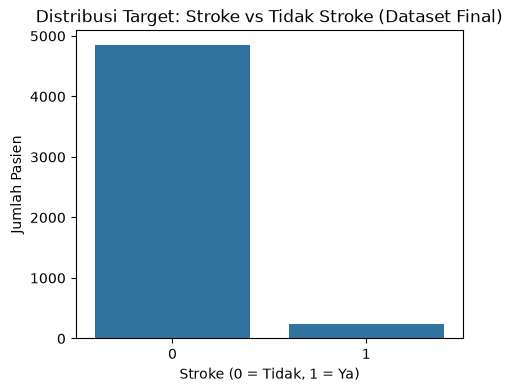

In [8]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = (df['stroke'].value_counts(normalize=True) * 100).round(2)

print("Distribusi kelas 'stroke' (dataset final):")
print(f"Tidak stroke (0): {stroke_counts[0]} ({stroke_pct[0]}%)")
print(f"Stroke (1)      : {stroke_counts[1]} ({stroke_pct[1]}%)")

plt.figure(figsize=(5,4))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Target: Stroke vs Tidak Stroke (Dataset Final)')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pasien')
plt.show()

**Insight:** Distribusi target pada dataset final (NB04) adalah 95.17% (tidak stroke) vs 4.83% (stroke) — hampir identik dengan temuan awal NB01 (95.13% vs 4.87%), mengonfirmasi bahwa proses cleaning tidak mengubah karakteristik inti dataset secara signifikan. Dataset tetap **imbalanced secara signifikan**, sehingga kesimpulan awal soal accuracy paradox dan kebutuhan evaluasi berbasis Recall/F1/Confusion Matrix (bukan accuracy) tetap berlaku sepenuhnya untuk tahap modeling.

## 3. Interpretasi & Implikasi

**Tujuan:** Menjelaskan dampak konkret dari imbalance yang ditemukan di Section 2 terhadap strategi evaluasi model — dengan mensimulasikan skenario "accuracy paradox" menggunakan angka nyata dari dataset ini.

In [16]:
total = len(df)
majority_class_count = df['stroke'].value_counts().max()
dummy_accuracy = majority_class_count / total * 100

actual_stroke = df['stroke'].sum()  
predicted_stroke_correctly = 0  
dummy_recall = predicted_stroke_correctly / actual_stroke * 100

print(f"Accuracy yang didapat: {dummy_accuracy:.2f}%")
print(f"Recall untuk kelas stroke: {dummy_recall:.2f}%")

Accuracy yang didapat: 95.17%
Recall untuk kelas stroke: 0.00%


**Interpretasi:**

Simulasi di atas membuktikan secara konkret fenomena **accuracy paradox**: sebuah model yang tidak belajar apapun (selalu menebak kelas mayoritas) tetap memperoleh accuracy sekitar 95% — angka yang sekilas terlihat sangat baik, padahal model tersebut **gagal total** mendeteksi satu pun pasien stroke (recall = 0%). Dalam konteks medis, ini adalah kegagalan fatal, karena tujuan utama model justru untuk mengidentifikasi pasien berisiko stroke, bukan mengonfirmasi pasien yang sehat.

Implikasi bagi tahap modeling (NB09-NB11):
1. **Accuracy tidak boleh dijadikan metrik utama** — angka tinggi bisa menyesatkan dan menutupi kegagalan model pada kelas minoritas.
2. **Recall menjadi prioritas** — mengukur seberapa banyak kasus stroke yang benar-benar berhasil terdeteksi model, sesuai kebutuhan sensitivitas tinggi dalam skrining kesehatan.
3. **F1-Score** digunakan sebagai penyeimbang antara recall dan precision, agar model tidak hanya "asal menebak stroke" demi mengejar recall tinggi.
4. **Confusion Matrix** ditampilkan secara eksplisit untuk memberikan gambaran utuh distribusi prediksi benar/salah pada kedua kelas, tidak hanya angka ringkasan tunggal.

Temuan ini juga menjadi salah satu justifikasi utama diterapkannya teknik penanganan imbalance (SMOTE atau `class_weight`) pada tahap persiapan data modeling (NB08).

## 4. Kesimpulan

**Tujuan:** Merangkum temuan analisis distribusi target menjadi kesimpulan akhir NB04, sebagai dasar keputusan strategi evaluasi model pada tahap modeling (NB09-NB11) dan penanganan imbalance pada tahap persiapan data (NB08).

**Kesimpulan Analisis Distribusi Target:**

Berdasarkan hasil pengecekan distribusi pada kolom `stroke` di dataset final (5.094 baris), diketahui bahwa dataset memiliki proporsi 95.17% data tidak stroke (kelas 0) dan 4.83% data stroke (kelas 1). Proporsi ini konsisten dengan temuan awal pada dataset asli di NB01 (95.13% vs 4.87%), mengonfirmasi bahwa karakteristik imbalance bersifat inheren pada data ini, bukan artefak dari proses corruption maupun cleaning.

Kondisi ini menunjukkan bahwa dataset termasuk **imbalanced dataset**, di mana jumlah data pada satu kelas jauh lebih banyak dibandingkan kelas lainnya. Simulasi model dummy (yang selalu memprediksi kelas mayoritas) membuktikan secara konkret risiko **accuracy paradox**: model semacam itu memperoleh accuracy 95.17% tanpa mempelajari pola apapun, sekaligus gagal total mendeteksi kasus stroke (recall 0%).

Oleh karena itu, pada penelitian ini evaluasi model tidak hanya berfokus pada accuracy, tetapi juga memperhatikan metrik seperti **Recall, F1-Score, dan Confusion Matrix**. Recall menjadi metrik yang sangat penting karena menunjukkan kemampuan model dalam mendeteksi pasien yang benar-benar mengalami stroke, sehingga lebih sesuai untuk kasus medis yang membutuhkan sensitivitas tinggi terhadap kelas minoritas. Temuan ini juga menjadi dasar penerapan teknik penanganan imbalance (SMOTE atau `class_weight`) pada tahap persiapan data modeling (NB08).